In [1]:
!git clone https://github.com/leeyeehoo/CSRNet-pytorch.git
%cd CSRNet-pytorch

Cloning into 'CSRNet-pytorch'...
remote: Enumerating objects: 86, done.
remote: Total 86 (delta 0), reused 0 (delta 0), pack-reused 86 (from 1)
Receiving objects: 100% (86/86), 622.25 KiB | 5.87 MiB/s, done.
Resolving deltas: 100% (47/47), done.
/content/CSRNet-pytorch


In [2]:
!pip install h5py scipy

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls /content/drive/MyDrive/ShanghaiTech/

ShanghaiTech  shanghaitech_h5_empty


In [5]:
!ls /content/drive/MyDrive/ShanghaiTech/ShanghaiTech/
!ls /content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/

part_A	part_B
ShanghaiTech


In [6]:
!ls /content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/
!ls /content/drive/MyDrive/ShanghaiTech/ShanghaiTech/part_A/


part_A	part_B
test_data  train_data


In [7]:
!ls /content/drive/MyDrive/ShanghaiTech/ShanghaiTech/part_A/train_data/
!ls /content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/

ground-truth  images
test_data  train_data


In [8]:
!find /content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/ -name "*.jpg" | head -3
!find /content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/ -name "*.mat" | head -3
!find /content/drive/MyDrive/ShanghaiTech/ShanghaiTech/part_A/ -name "*.jpg" | head -3
!find /content/drive/MyDrive/ShanghaiTech/ShanghaiTech/part_A/ -name "*.mat" | head -3

/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/train_data/images/IMG_115.jpg
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/train_data/images/IMG_16.jpg
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/train_data/images/IMG_206.jpg
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/train_data/ground-truth/GT_IMG_299.mat
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/train_data/ground-truth/GT_IMG_102.mat
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/train_data/ground-truth/GT_IMG_200.mat
/content/drive/MyDrive/ShanghaiTech/ShanghaiTech/part_A/train_data/images/IMG_124.jpg
/content/drive/MyDrive/ShanghaiTech/ShanghaiTech/part_A/train_data/images/IMG_183.jpg
/content/drive/MyDrive/ShanghaiTech/ShanghaiTech/part_A/train_data/images/IMG_135.jpg
/content/drive/MyDrive/ShanghaiTech/ShanghaiTech/part_A/train_data/g

In [9]:
!git clone https://github.com/leeyeehoo/CSRNet-pytorch.git
%cd /content/CSRNet-pytorch

!sed -i 's/xrange/range/g' model.py
!sed -i "s/self.frontend.state_dict().items()\[i\]\[1\].data\[:\] = mod.state_dict().items()\[i\]\[1\].data\[:\]/list(self.frontend.state_dict().items())[i][1].data[:] = list(mod.state_dict().items())[i][1].data[:]/" model.py
!sed -i 's/ground_truth/ground-truth/g' image.py
!sed -i 's|target.shape\[1\]/8|target.shape[1]//8|g' image.py
!sed -i 's|target.shape\[0\]/8|target.shape[0]//8|g' image.py

print("Repo ready!")

Cloning into 'CSRNet-pytorch'...
remote: Enumerating objects: 86, done.
remote: Total 86 (delta 0), reused 0 (delta 0), pack-reused 86 (from 1)
Receiving objects: 100% (86/86), 622.25 KiB | 5.61 MiB/s, done.
Resolving deltas: 100% (47/47), done.
/content/CSRNet-pytorch
Repo ready!


In [ ]:
# import os
# import json

# # Yolları kendi yapına göre düzenle
# h5_root = '/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech_part_A'
# img_root = '/content/drive/MyDrive/ShanghaiTech/ShanghaiTech/part_A'

# train_list = sorted([
#     os.path.join(img_root, 'train_data/images', f)
#     for f in os.listdir(os.path.join(img_root, 'train_data/images'))
#     if f.endswith('.jpg')
# ])

# test_list = sorted([
#     os.path.join(img_root, 'test_data/images', f)
#     for f in os.listdir(os.path.join(img_root, 'test_data/images'))
#     if f.endswith('.jpg')
# ])

# with open('train.json', 'w') as f:
#     json.dump(train_list, f)
# with open('test.json', 'w') as f:
#     json.dump(test_list, f)

# print(f"Train: {len(train_list)}, Test: {len(test_list)}")

Train: 300, Test: 182


In [11]:

import os, glob, h5py, numpy as np, scipy.io as io
from scipy.ndimage import gaussian_filter
from PIL import Image

def make_density(img_path, mat_path):
    img = Image.open(img_path)
    mat = io.loadmat(mat_path)
    points = mat['image_info'][0,0][0,0][0]
    k = np.zeros((img.size[1], img.size[0]))
    for pt in points:
        x, y = min(int(pt[0]), img.size[0]-1), min(int(pt[1]), img.size[1]-1)
        k[y, x] = 1
    return gaussian_filter(k, sigma=15, mode='constant')

root = '/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A'

for split in ['train_data', 'test_data']:
    img_dir = os.path.join(root, split, 'images')
    gt_dir = os.path.join(root, split, 'ground-truth')
    imgs = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
    print(f"\n{split}: {len(imgs)} images")
    for i, img_path in enumerate(imgs):
        fname = os.path.basename(img_path).replace('.jpg','')
        mat_path = os.path.join(gt_dir, f'GT_{fname}.mat')
        density = make_density(img_path, mat_path)
        h5_path = img_path.replace('.jpg','.h5').replace('images','ground-truth')
        with h5py.File(h5_path, 'w') as hf:
            hf['density'] = density
        if i % 50 == 0:
            print(f"  {i}/{len(imgs)} - count: {density.sum():.1f}")
    print(f"{split} done!")


train_data: 300 images
  0/300 - count: 1535.9
  50/300 - count: 776.0
  100/300 - count: 702.3
  150/300 - count: 458.4
  200/300 - count: 791.7
  250/300 - count: 505.9
train_data done!

test_data: 182 images
  0/182 - count: 171.5
  50/182 - count: 249.2
  100/182 - count: 241.7
  150/182 - count: 402.0
test_data done!


In [13]:
# ============ STEP 3 - Create JSON lists ============
import json
train_list = sorted(glob.glob(os.path.join(root, 'train_data/images/*.jpg')))
test_list = sorted(glob.glob(os.path.join(root, 'test_data/images/*.jpg')))
with open('train.json', 'w') as f: json.dump(train_list, f)
with open('test.json', 'w') as f: json.dump(test_list, f)
print(f"Train: {len(train_list)}, Test: {len(test_list)}")

Train: 300, Test: 182


In [14]:

import torch
print("GPU:", torch.cuda.get_device_name(0))

!python train.py train.json test.json 0 0

GPU: NVIDIA A100-SXM4-40GB
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100% 528M/528M [00:02<00:00, 218MB/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = 

In [15]:
!ls -la /content/CSRNet-pytorch/*.pth*
!grep -n "save_checkpoint\|torch.save\|model_best" train.py

-rw-r--r-- 1 root root 130131820 Apr  8 16:46 /content/CSRNet-pytorch/0checkpoint.pth.tar
-rw-r--r-- 1 root root 130131820 Apr  8 16:46 /content/CSRNet-pytorch/0model_best.pth.tar
8:from utils import save_checkpoint
99:        save_checkpoint({


In [16]:
import torch
c = torch.load('/content/CSRNet-pytorch/0model_best.pth.tar')
print("Epoch:", c['epoch'])
print("Best MAE:", c['best_prec1'])

Epoch: 36
Best MAE: tensor(70.1899, device='cuda:0')


In [18]:
!cp /content/CSRNet-pytorch/0model_best.pth.tar /content/drive/MyDrive/csrnet_best.pth.tar

In [19]:
checkpoint = torch.load('/content/CSRNet-pytorch/0model_best.pth.tar')

In [20]:
import torch
import cv2
import numpy as np
from model import CSRNet
from torchvision import transforms
from PIL import Image
from google.colab.patches import cv2_imshow

# Load model
model = CSRNet()
checkpoint = torch.load('/content/drive/MyDrive/csrnet_best.pth.tar')
model.load_state_dict(checkpoint['state_dict'])
model.eval().cuda()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Process video
video_path = '/content/drive/MyDrive/your_video.mp4'  # CHANGE THIS
cap = cv2.VideoCapture(video_path)

# Output video
fps = int(cap.get(cv2.CAP_PROP_FPS))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter('/content/output.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    img_tensor = transform(img).unsqueeze(0).cuda()

    with torch.no_grad():
        density = model(img_tensor)
        count = density.sum().item()

    # Add count text on frame
    cv2.putText(frame, f'Count: {int(count)}', (20, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 3)

    out.write(frame)
    frame_count += 1
    if frame_count % 30 == 0:
        print(f"Frame {frame_count} - Count: {count:.1f}")

cap.release()
out.release()
print("Done! Output saved to /content/output.mp4")

Frame 30 - Count: 45.7
Frame 60 - Count: 48.5
Frame 90 - Count: 47.1
Frame 120 - Count: 46.9
Frame 150 - Count: 47.4
Frame 180 - Count: 47.6
Frame 210 - Count: 42.0
Frame 240 - Count: 43.1
Frame 270 - Count: 46.2
Frame 300 - Count: 45.4
Frame 330 - Count: 43.1
Frame 360 - Count: 43.3
Frame 390 - Count: 45.5
Frame 420 - Count: 43.5
Frame 450 - Count: 43.4
Frame 480 - Count: 44.4
Frame 510 - Count: 43.9
Frame 540 - Count: 49.4
Frame 570 - Count: 47.1
Frame 600 - Count: 49.1
Frame 630 - Count: 49.4
Frame 660 - Count: 46.0
Frame 690 - Count: 45.2
Frame 720 - Count: 46.7
Frame 750 - Count: 45.2
Frame 780 - Count: 45.8
Frame 810 - Count: 43.6
Frame 840 - Count: 46.4
Frame 870 - Count: 43.0
Frame 900 - Count: 43.2
Frame 930 - Count: 46.9
Frame 960 - Count: 46.4
Frame 990 - Count: 47.2
Frame 1020 - Count: 47.4
Frame 1050 - Count: 45.8
Frame 1080 - Count: 46.2
Frame 1110 - Count: 44.7
Frame 1140 - Count: 44.4
Frame 1170 - Count: 48.5
Frame 1200 - Count: 48.0
Frame 1230 - Count: 41.3
Frame 1260 

In [21]:
import torch
import cv2
import numpy as np
from model import CSRNet
from torchvision import transforms
from PIL import Image

model = CSRNet()
checkpoint = torch.load('/content/CSRNet-pytorch/0model_best.pth.tar')
model.load_state_dict(checkpoint['state_dict'])
model.eval().cuda()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

video_path = '/content/drive/MyDrive/your_video.mp4'  # CHANGE THIS
cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter('/content/output_heatmap.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    img_tensor = transform(img).unsqueeze(0).cuda()

    with torch.no_grad():
        density = model(img_tensor)
        count = density.sum().item()

    # Create heatmap overlay
    density_np = density.squeeze().cpu().numpy()
    density_np = cv2.resize(density_np, (w, h))
    density_np = np.clip(density_np, 0, np.max(density_np))
    if density_np.max() > 0:
        density_np = (density_np / density_np.max() * 255).astype(np.uint8)
    else:
        density_np = np.zeros((h, w), dtype=np.uint8)

    heatmap = cv2.applyColorMap(density_np, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(frame, 0.6, heatmap, 0.4, 0)

    # Add count text
    cv2.putText(overlay, f'Count: {int(count)}', (20, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 3)

    out.write(overlay)
    frame_count += 1
    if frame_count % 100 == 0:
        print(f"Frame {frame_count} - Count: {count:.1f}")

cap.release()
out.release()
print("Done!")

# Copy to Drive
!cp /content/output_heatmap.mp4 /content/drive/MyDrive/csrnet_output_heatmap.mp4

Frame 100 - Count: 45.7
Frame 200 - Count: 44.7
Frame 300 - Count: 45.4
Frame 400 - Count: 46.5
Frame 500 - Count: 45.7
Frame 600 - Count: 49.1
Frame 700 - Count: 45.3
Frame 800 - Count: 42.7
Frame 900 - Count: 43.2
Frame 1000 - Count: 49.5
Frame 1100 - Count: 46.7
Frame 1200 - Count: 48.0
Frame 1300 - Count: 47.0


KeyboardInterrupt: 

In [22]:
import torch, cv2, numpy as np
from model import CSRNet
from torchvision import transforms
from PIL import Image

model = CSRNet()
checkpoint = torch.load('/content/CSRNet-pytorch/0model_best.pth.tar')
model.load_state_dict(checkpoint['state_dict'])
model.eval().cuda()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

video_path = '/content/drive/MyDrive/your_video.mp4'  # CHANGE THIS
cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter('/content/output.avi', cv2.VideoWriter_fourcc(*'XVID'), fps, (w, h))

frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    img_tensor = transform(img).unsqueeze(0).cuda()

    with torch.no_grad():
        density = model(img_tensor)
        count = density.sum().item()

    # Black bar at top
    cv2.rectangle(frame, (0, 0), (w, 80), (0, 0, 0), -1)
    cv2.putText(frame, f'People Count: {int(count)}', (20, 55),
                cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 255, 0), 3)

    out.write(frame)
    frame_count += 1
    if frame_count % 100 == 0:
        print(f"Frame {frame_count} - Count: {count:.1f}")

cap.release()
out.release()

# Convert to mp4 for playback
!ffmpeg -y -i /content/output.avi -c:v libx264 /content/output_final.mp4 -loglevel quiet
print("Done!")

Frame 100 - Count: 45.7
Frame 200 - Count: 44.7
Frame 300 - Count: 45.4
Frame 400 - Count: 46.5
Frame 500 - Count: 45.7
Frame 600 - Count: 49.1
Frame 700 - Count: 45.3
Frame 800 - Count: 42.7
Frame 900 - Count: 43.2
Frame 1000 - Count: 49.5
Frame 1100 - Count: 46.7
Frame 1200 - Count: 48.0
Frame 1300 - Count: 47.0
Frame 1400 - Count: 46.5
Frame 1500 - Count: 46.1
Frame 1600 - Count: 52.0
Frame 1700 - Count: 53.0
Frame 1800 - Count: 53.0
Frame 1900 - Count: 50.3
Frame 2000 - Count: 49.7
Frame 2100 - Count: 46.4
Frame 2200 - Count: 47.2
Frame 2300 - Count: 46.3
Frame 2400 - Count: 45.1
Frame 2500 - Count: 43.0
Frame 2600 - Count: 44.5
Frame 2700 - Count: 49.4
Frame 2800 - Count: 50.7
Frame 2900 - Count: 52.9
Frame 3000 - Count: 46.2
Frame 3100 - Count: 50.6
Frame 3200 - Count: 49.1
Frame 3300 - Count: 48.9
Frame 3400 - Count: 46.2
Frame 3500 - Count: 42.6
Frame 3600 - Count: 47.7
Frame 3700 - Count: 47.2
Done!


In [23]:
from IPython.display import HTML
from base64 import b64encode

video_data = open('/content/output_final.mp4', 'rb').read()
b64 = b64encode(video_data).decode()
HTML(f'<video controls width="800"><source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>')

Output hidden; open in https://colab.research.google.com to view.

In [24]:
!pip install ultralytics

# Run detection on video
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # auto-downloads

video_path = '/content/drive/MyDrive/your_video.mp4'  # CHANGE THIS

results = model.predict(
    source=video_path,
    classes=[0],  # 0 = person only
    save=True,
    conf=0.3,
    line_width=2
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/3727) /content/drive/MyDrive/your_video.mp4: 384x64

In [25]:
import cv2
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
video_path = '/content/drive/MyDrive/your_video.mp4'  # CHANGE THIS

cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter('/content/output.avi', cv2.VideoWriter_fourcc(*'XVID'), fps, (w, h))

frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, classes=[0], conf=0.3, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    count = len(boxes)

    # Draw box around each person
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Black bar + count at top
    cv2.rectangle(frame, (0, 0), (w, 80), (0, 0, 0), -1)
    cv2.putText(frame, f'People Count: {count}', (20, 55),
                cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 255, 0), 3)

    out.write(frame)
    frame_count += 1
    if frame_count % 100 == 0:
        print(f"Frame {frame_count} - Count: {count}")

cap.release()
out.release()

!ffmpeg -y -i /content/output.avi -c:v libx264 /content/output_final.mp4 -loglevel quiet
print("Done!")

Frame 100 - Count: 10
Frame 200 - Count: 16
Frame 300 - Count: 16
Frame 400 - Count: 17
Frame 500 - Count: 13
Frame 600 - Count: 11
Frame 700 - Count: 14
Frame 800 - Count: 15
Frame 900 - Count: 14
Frame 1000 - Count: 15
Frame 1100 - Count: 18
Frame 1200 - Count: 14
Frame 1300 - Count: 18
Frame 1400 - Count: 14
Frame 1500 - Count: 10
Frame 1600 - Count: 14
Frame 1700 - Count: 10
Frame 1800 - Count: 13
Frame 1900 - Count: 11
Frame 2000 - Count: 12
Frame 2100 - Count: 12
Frame 2200 - Count: 12
Frame 2300 - Count: 16
Frame 2400 - Count: 14
Frame 2500 - Count: 11
Frame 2600 - Count: 9
Frame 2700 - Count: 10
Frame 2800 - Count: 10
Frame 2900 - Count: 11
Frame 3000 - Count: 12
Frame 3100 - Count: 13
Frame 3200 - Count: 12
Frame 3300 - Count: 8
Frame 3400 - Count: 9
Frame 3500 - Count: 11
Frame 3600 - Count: 7
Frame 3700 - Count: 8
Done!


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


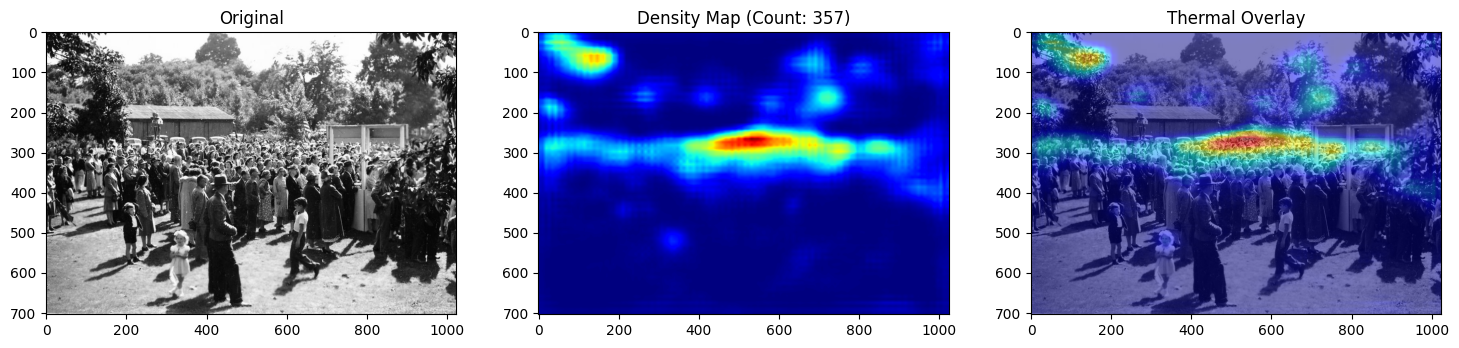

In [28]:
import torch, cv2, numpy as np
from model import CSRNet
from torchvision import transforms
from PIL import Image

model = CSRNet()
checkpoint = torch.load('/content/CSRNet-pytorch/0model_best.pth.tar')
model.load_state_dict(checkpoint['state_dict'])
model.eval().cuda()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# For single image
img = Image.open('/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/test_data/images/IMG_1.jpg')
img_tensor = transform(img).unsqueeze(0).cuda()
with torch.no_grad():
    density = model(img_tensor)
    count = density.sum().item()

density_np = density.squeeze().cpu().numpy()
density_np = cv2.resize(density_np, (img.size[0], img.size[1]))
if density_np.max() > 0:
    density_np = (density_np / density_np.max() * 255).astype(np.uint8)
heatmap = cv2.applyColorMap(density_np, cv2.COLORMAP_JET)

original = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
overlay = cv2.addWeighted(original, 0.5, heatmap, 0.5, 0)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[1].imshow(density_np, cmap='jet')
axes[1].set_title(f'Density Map (Count: {count:.0f})')
axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title('Thermal Overlay')
plt.show()

In [29]:
# Save model
!cp /content/CSRNet-pytorch/0model_best.pth.tar /content/drive/MyDrive/csrnet_best.pth.tar

# Save entire CSRNet project (with all fixes)
!cp -r /content/CSRNet-pytorch /content/drive/MyDrive/CSRNet-pytorch

print("Everything saved to Drive!")

Everything saved to Drive!


In [ ]:
!cat dataset.py

import os
import random
import torch
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
from image import *
import torchvision.transforms.functional as F

class listDataset(Dataset):
    def __init__(self, root, shape=None, shuffle=True, transform=None,  train=False, seen=0, batch_size=1, num_workers=4):
        if train:
            root = root *4
        random.shuffle(root)
        
        self.nSamples = len(root)
        self.lines = root
        self.transform = transform
        self.train = train
        self.shape = shape
        self.seen = seen
        self.batch_size = batch_size
        self.num_workers = num_workers
        
        
    def __len__(self):
        return self.nSamples
    def __getitem__(self, index):
        assert index <= len(self), 'index range error' 
        
        img_path = self.lines[index]
        
        img,target = load_data(img_path,self.train)
        
        #img = 255.0 * F.to_tensor(img)
        
        #

In [ ]:
!cat image.py

import random
import os
from PIL import Image,ImageFilter,ImageDraw
import numpy as np
import h5py
from PIL import ImageStat
import cv2

def load_data(img_path,train = True):
    gt_path = img_path.replace('.jpg','.h5').replace('images','ground_truth')
    img = Image.open(img_path).convert('RGB')
    gt_file = h5py.File(gt_path)
    target = np.asarray(gt_file['density'])
    if False:
        crop_size = (img.size[0]/2,img.size[1]/2)
        if random.randint(0,9)<= -1:
            
            
            dx = int(random.randint(0,1)*img.size[0]*1./2)
            dy = int(random.randint(0,1)*img.size[1]*1./2)
        else:
            dx = int(random.random()*img.size[0]*1./2)
            dy = int(random.random()*img.size[1]*1./2)
        
        
        
        img = img.crop((dx,dy,crop_size[0]+dx,crop_size[1]+dy))
        target = target[dy:crop_size[1]+dy,dx:crop_size[0]+dx]
        
        
        
        
        if random.random()>0.8:
            target = np.fliplr(ta

In [ ]:
!find /content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty -name "*.h5" | head -5


/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/test_data/ground-truth/IMG_1.h5
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/test_data/ground-truth/IMG_10.h5
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/test_data/ground-truth/IMG_100.h5
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/test_data/ground-truth/IMG_101.h5
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/test_data/ground-truth/IMG_102.h5


In [ ]:
!find /content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty -type d


/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/test_data
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/test_data/images
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/test_data/ground-truth
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/train_data
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/train_data/images
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/train_data/ground-truth
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_B
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_B/train_data
/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_emp

In [ ]:
!ls /content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/train_data/images/ | head -3
!ls /content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/train_data/ground-truth/ | head -3

IMG_100.jpg
IMG_101.jpg
IMG_102.jpg
GT_IMG_100.mat
GT_IMG_101.mat
GT_IMG_102.mat


In [ ]:
import os
import glob
import h5py
import scipy.io as io
import numpy as np
from scipy.ndimage import gaussian_filter
from PIL import Image

def make_density(img_path, mat_path):
    img = Image.open(img_path)
    mat = io.loadmat(mat_path)
    points = mat['image_info'][0,0][0,0][0]  # x,y coordinates

    k = np.zeros((img.size[1], img.size[0]))
    for pt in points:
        x, y = min(int(pt[0]), img.size[0]-1), min(int(pt[1]), img.size[1]-1)
        k[y, x] = 1

    density = gaussian_filter(k, sigma=15, mode='constant')
    return density

root = '/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A'

for split in ['train_data', 'test_data']:
    img_dir = os.path.join(root, split, 'images')
    gt_dir = os.path.join(root, split, 'ground-truth')

    imgs = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
    print(f"\n{split}: {len(imgs)} images to process")

    for i, img_path in enumerate(imgs):
        fname = os.path.basename(img_path).replace('.jpg','')
        mat_path = os.path.join(gt_dir, f'GT_{fname}.mat')

        density = make_density(img_path, mat_path)

        h5_path = img_path.replace('.jpg', '.h5').replace('images', 'ground-truth')
        with h5py.File(h5_path, 'w') as hf:
            hf['density'] = density

        if i % 20 == 0:
            print(f"  {i}/{len(imgs)} - {fname} - count: {density.sum():.1f}")

    print(f"{split} done!")


train_data: 300 images to process
  0/300 - IMG_1 - count: 1535.9
  20/300 - IMG_117 - count: 354.4
  40/300 - IMG_135 - count: 326.2
  60/300 - IMG_153 - count: 674.0
  80/300 - IMG_171 - count: 1336.8
  100/300 - IMG_19 - count: 702.3
  120/300 - IMG_207 - count: 126.5
  140/300 - IMG_225 - count: 462.7
  160/300 - IMG_243 - count: 121.7


KeyboardInterrupt: 

In [ ]:
!ls /content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A/train_data/ground-truth/*.h5 | head -3


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
gt_path = img_path.replace('.jpg','.h5').replace('images','ground-truth')

In [ ]:
import os, json, glob

root = '/content/drive/MyDrive/ShanghaiTech/shanghaitech_h5_empty/ShanghaiTech/part_A'

train_list = sorted(glob.glob(os.path.join(root, 'train_data/images/*.jpg')))
test_list = sorted(glob.glob(os.path.join(root, 'test_data/images/*.jpg')))

with open('/content/CSRNet-pytorch/train.json', 'w') as f:
    json.dump(train_list, f)
with open('/content/CSRNet-pytorch/test.json', 'w') as f:
    json.dump(test_list, f)

print(f"Train: {len(train_list)}, Test: {len(test_list)}")


Train: 300, Test: 182


In [ ]:
%cd /content/CSRNet-pytorch
!python train.py train.json test.json 0 0

/content/CSRNet-pytorch
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100% 528M/528M [00:03<00:00, 173MB/s]
Traceback (most recent call last):
  File "/content/CSRNet-pytorch/train.py", line 230, in <module>
    main()        
    ^^^^^^
  File "/content/CSRNet-pytorch/train.py", line 65, in main
    

In [ ]:
!sed -i 's/xrange/range/g' /content/CSRNet-pytorch/model.py

In [ ]:
!python train.py train.json test.json 0 0

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Traceback (most recent call last):
  File "/content/CSRNet-pytorch/train.py", line 230, in <module>
    main()        
    ^^^^^^
  File "/content/CSRNet-pytorch/train.py", line 65, in main
    model = CSRNet()
            ^^^^^^^^
  File "/content/CSRNet-pytorch/model.py", line 19, in __init__
    self.frontend.state_dict().items()[i][1].data[:] = mod.state_dict().items()[i][1].d

In [ ]:
!sed -i 's/self.frontend.state_dict().items()\[i\]\[1\].data\[:\] = mod.state_dict().items()\[i\]\[1\].data\[:\]/list(self.frontend.state_dict().items())[i][1].data[:] = list(mod.state_dict().items())[i][1].data[:]/' /content/CSRNet-pytorch/model.py

In [ ]:
!head -80 /content/CSRNet-pytorch/train.py

import sys
import os

import warnings

from model import CSRNet

from utils import save_checkpoint

import torch
import torch.nn as nn
from torch.autograd import Variable
from torchvision import datasets, transforms

import numpy as np
import argparse
import json
import cv2
import dataset
import time

parser = argparse.ArgumentParser(description='PyTorch CSRNet')

parser.add_argument('train_json', metavar='TRAIN',
                    help='path to train json')
parser.add_argument('test_json', metavar='TEST',
                    help='path to test json')

parser.add_argument('--pre', '-p', metavar='PRETRAINED', default=None,type=str,
                    help='path to the pretrained model')

parser.add_argument('gpu',metavar='GPU', type=str,
                    help='GPU id to use.')

parser.add_argument('task',metavar='TASK', type=str,
                    help='task id to use.')

def main():
    
    global args,best_prec1
    
    best_prec1 = 1e6
    
    args = parser.parse_args()
  

In [ ]:
!python train.py train.json test.json 0 0

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)
epoch 0, processed 0 samples, lr 0.0000001000
Traceback (most recent call last):
  File "/content/CSRNet-pytorch/train.py", line 230, in <mod

In [ ]:
!sed -i "s/ground_truth/ground-truth/g" /content/CSRNet-pytorch/image.py

In [ ]:
!python train.py train.json test.json 0 0

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)
epoch 0, processed 0 samples, lr 0.0000001000
Traceback (most recent call last):
  File "/content/CSRNet-pytorch/train.py", line 230, in <mod

In [ ]:
!sed -i 's|target.shape\[1\]/8|target.shape[1]//8|g' /content/CSRNet-pytorch/image.py
!sed -i 's|target.shape\[0\]/8|target.shape[0]//8|g' /content/CSRNet-pytorch/image.py

In [ ]:
!python train.py train.json test.json 0 0

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)
epoch 0, processed 0 samples, lr 0.0000001000
Epoch: [0][0/1200]	Time 1.529 (1.529)	Data 0.272 (0.272)	Loss 1.1429 (1.1429)	
Epoch: [0][30/12